In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [3]:
print(X.shape)


(150, 4)


In [4]:
print(X[:5])


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [5]:
print(feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [7]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [8]:
print(y[:5])

[0 0 0 0 0]


In [9]:
print("Features:", X[0])
print("Label:", y[0])
print("Flower Name:", iris.target_names[y[0]])

Features: [5.1 3.5 1.4 0.2]
Label: 0
Flower Name: setosa


In [10]:
scaler = StandardScaler()

In [12]:
X_scaled = scaler.fit_transform(X)

In [13]:
print(X_scaled[:5])


[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [14]:
print(np.round(X_scaled.mean(axis=0), 3))
print(np.round(X_scaled.std(axis=0), 3))

[-0. -0. -0. -0.]
[1. 1. 1. 1.]


In [15]:
cov_matrix = np.cov(X_scaled.T)

In [16]:
print(np.round(cov_matrix, 3))

[[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]


In [17]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [18]:
print(eigen_values)

[2.93808505 0.9201649  0.14774182 0.02085386]


In [19]:
sorted_idx = np.argsort(eigen_values)[::-1]

In [20]:
print(sorted_idx)


[0 1 2 3]


In [21]:
eigen_values = eigen_values[sorted_idx]

In [22]:
eigen_vectors = eigen_vectors[:, sorted_idx]

In [23]:
k = 2
projection_matrix = eigen_vectors[:, :k]

In [24]:
print(projection_matrix)

[[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


In [25]:
X_pca_scratch = X_scaled.dot(projection_matrix)

In [26]:
print(X_pca_scratch.shape)

(150, 2)


In [27]:
print(X_pca_scratch[:5])

[[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]]


In [28]:
pca = PCA(n_components=2)

In [29]:
X_pca_sklearn = pca.fit_transform(X_scaled)

In [30]:
print(X_pca_sklearn.shape)

(150, 2)


In [31]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [32]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [33]:
print(np.sum(pca.explained_variance_ratio_))

0.9581320720000164


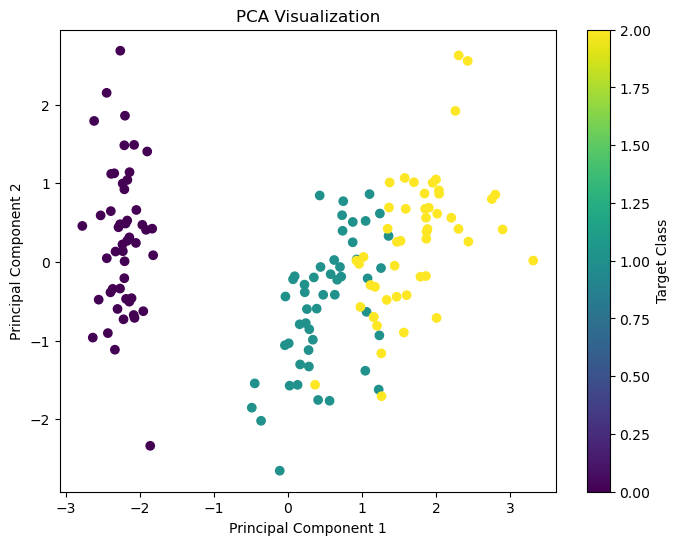

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_sklearn[:,0],
    X_pca_sklearn[:,1],
    c=y,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.colorbar(label="Target Class")

plt.show()